In [ ]:
# Student Performance Analytics: Identifying Factors Affecting Exam Scores

**Data Analyst Portfolio Project**

---

**Prepared by:** Bidhan Banjade
**Role:** Aspiring Data Analyst
**Tools Used:** PostgreSQL, Python, pandas, Jupyter Notebook, matplotlib
**Project Type:** Exploratory Data Analysis and SQL-Based Analytics
**Date:** July 2026

---

## Project Overview

This project analyzes student exam performance data to identify the factors that may influence academic scores. The analysis focuses on variables such as gender, parental level of education, lunch type, test preparation course, and exam scores in math, reading, and writing.

The main goal of this project is to use SQL and Python to clean, analyze, and visualize student performance data, then generate meaningful insights that can support data-driven academic decision-making.

In [38]:
%pip install psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 3.4 MB/s  0:00:01 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
import psycopg2
print("psycopg2 installed successfully")

psycopg2 installed successfully


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import getpass

In [7]:
db_user = "bidhanbanjade"
db_password = getpass.getpass("Enter your PostgreSQL password: ")
db_host = "localhost"
db_port = "5432"
db_name = "student_performance_db"

connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username=db_user,
    password=db_password,
    host=db_host,
    port=db_port,
    database=db_name
)

engine = create_engine(connection_url)

print("Database connection successful.")

Enter your PostgreSQL password:  ········


Database connection successful.


In [9]:
query = """
SELECT *
FROM student_performance_analysis
LIMIT 10;
"""

df_test = pd.read_sql(query, engine)
df_test

,student_id,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score,performance_level
0,1,female,group B,bachelor's degree,standard,none,72,72,74,218,72.67,Average Performer
1,2,female,group C,some college,standard,completed,69,90,88,247,82.33,High Performer
2,3,female,group B,master's degree,standard,none,90,95,93,278,92.67,High Performer
3,4,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.33,Low Performer
4,5,male,group C,some college,standard,none,76,78,75,229,76.33,Average Performer
5,6,female,group B,associate's degree,standard,none,71,83,78,232,77.33,Average Performer
6,7,female,group B,some college,standard,completed,88,95,92,275,91.67,High Performer
7,8,male,group B,some college,free/reduced,none,40,43,39,122,40.67,Low Performer
8,9,male,group D,high school,free/reduced,completed,64,64,67,195,65.00,Average Performer
9,10,female,group B,high school,free/reduced,none,38,60,50,148,49.33,Low Performer


In [11]:
query = """
SELECT *
FROM student_performance_analysis;
"""

df = pd.read_sql(query, engine)

df.head()

,student_id,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score,performance_level
0,1,female,group B,bachelor's degree,standard,none,72,72,74,218,72.67,Average Performer
1,2,female,group C,some college,standard,completed,69,90,88,247,82.33,High Performer
2,3,female,group B,master's degree,standard,none,90,95,93,278,92.67,High Performer
3,4,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.33,Low Performer
4,5,male,group C,some college,standard,none,76,78,75,229,76.33,Average Performer


In [13]:
df.shape

(1000, 12)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   student_id                   1000 non-null   int64  
 1   gender                       1000 non-null   object 
 2   race_ethnicity               1000 non-null   object 
 3   parental_level_of_education  1000 non-null   object 
 4   lunch                        1000 non-null   object 
 5   test_preparation_course      1000 non-null   object 
 6   math_score                   1000 non-null   int64  
 7   reading_score                1000 non-null   int64  
 8   writing_score                1000 non-null   int64  
 9   total_score                  1000 non-null   int64  
 10  average_score                1000 non-null   float64
 11  performance_level            1000 non-null   object 
dtypes: float64(1), int64(5), object(6)
memory usage: 93.9+ KB


In [17]:
df.describe()

,student_id,math_score,reading_score,writing_score,total_score,average_score
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,66.08900,69.169000,68.054000,203.312000,67.770580
std,288.819436,15.16308,14.600192,15.195657,42.771978,14.257311
min,1.000000,0.00000,17.000000,10.000000,27.000000,9.000000
25%,250.750000,57.00000,59.000000,57.750000,175.000000,58.330000
50%,500.500000,66.00000,70.000000,69.000000,205.000000,68.330000
75%,750.250000,77.00000,79.000000,79.000000,233.000000,77.670000
max,1000.000000,100.00000,100.000000,100.000000,300.000000,100.000000


In [ ]:
## Data Loading and Initial Exploration

The cleaned SQL view `student_performance_analysis` was loaded from PostgreSQL into a pandas DataFrame. This view includes the original student performance variables along with calculated fields such as total score, average score, and performance level.

The purpose of this section is to inspect the dataset structure, check the number of records, review data types, and understand the basic score distribution.

In [19]:
df.isnull().sum()

student_id                     0
gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
total_score                    0
average_score                  0
performance_level              0
dtype: int64

In [ ]:
## Missing Value Check

The dataset was checked for missing values across all columns. This step helps confirm whether additional data cleaning is required before performing analysis and visualization.

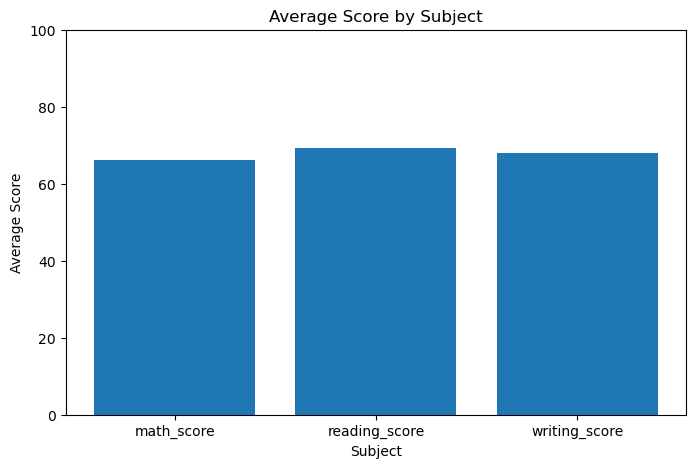

In [21]:
subject_avg = df[["math_score", "reading_score", "writing_score"]].mean()

plt.figure(figsize=(8, 5))
plt.bar(subject_avg.index, subject_avg.values)
plt.title("Average Score by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.ylim(0, 100)
plt.show()

In [ ]:
### Insight: Average Score by Subject

This chart compares the average scores for math, reading, and writing. It helps identify which subject students performed better in overall.

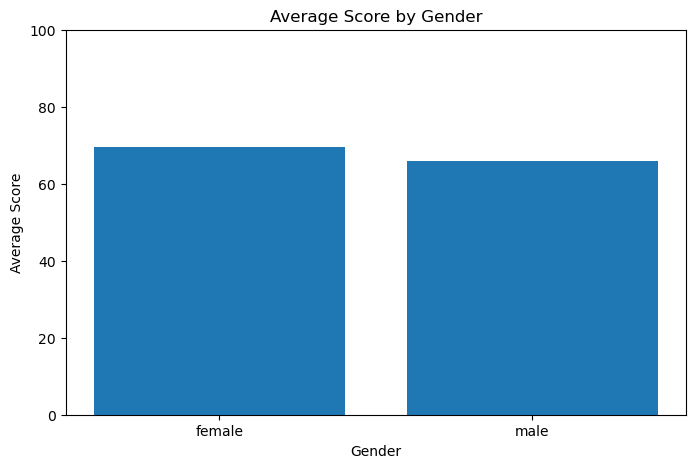

In [23]:
gender_avg = df.groupby("gender")["average_score"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(gender_avg.index, gender_avg.values)
plt.title("Average Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.ylim(0, 100)
plt.show()

In [ ]:
### Insight: Average Score by Gender

This chart shows the difference in average exam performance between male and female students. The average score is calculated using math, reading, and writing scores.

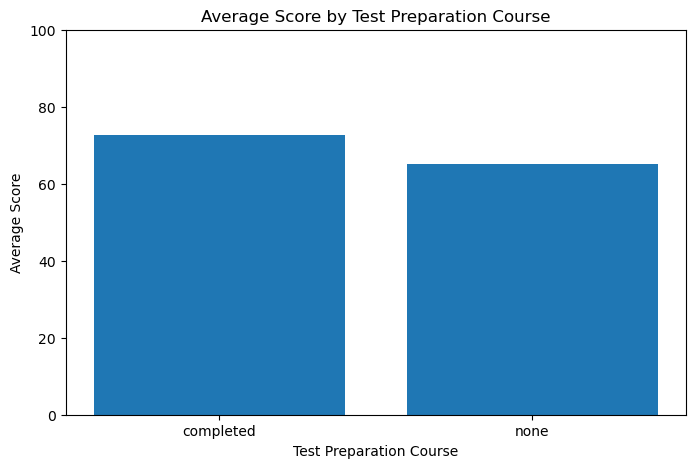

In [25]:
test_prep_avg = df.groupby("test_preparation_course")["average_score"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(test_prep_avg.index, test_prep_avg.values)
plt.title("Average Score by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.ylim(0, 100)
plt.show()

In [ ]:
### Insight: Test Preparation and Student Performance

This chart compares students who completed the test preparation course with those who did not. It helps evaluate whether test preparation is associated with higher average exam performance.

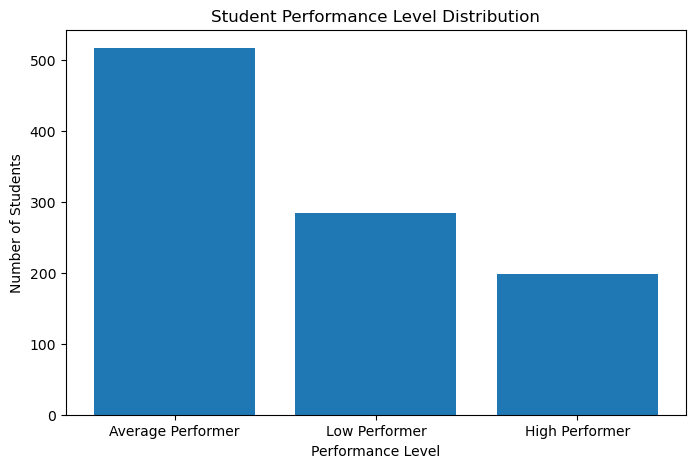

In [29]:
performance_counts = df["performance_level"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(performance_counts.index, performance_counts.values)
plt.title("Student Performance Level Distribution")
plt.xlabel("Performance Level")
plt.ylabel("Number of Students")
plt.show()

In [ ]:
### Insight: Performance Level Distribution

This chart shows how students are distributed across high, average, and low performance categories based on their overall average exam score.

In [ ]:
## Analysis by Parental Level of Education

This section analyzes whether students' average exam performance differs based on their parents' level of education.

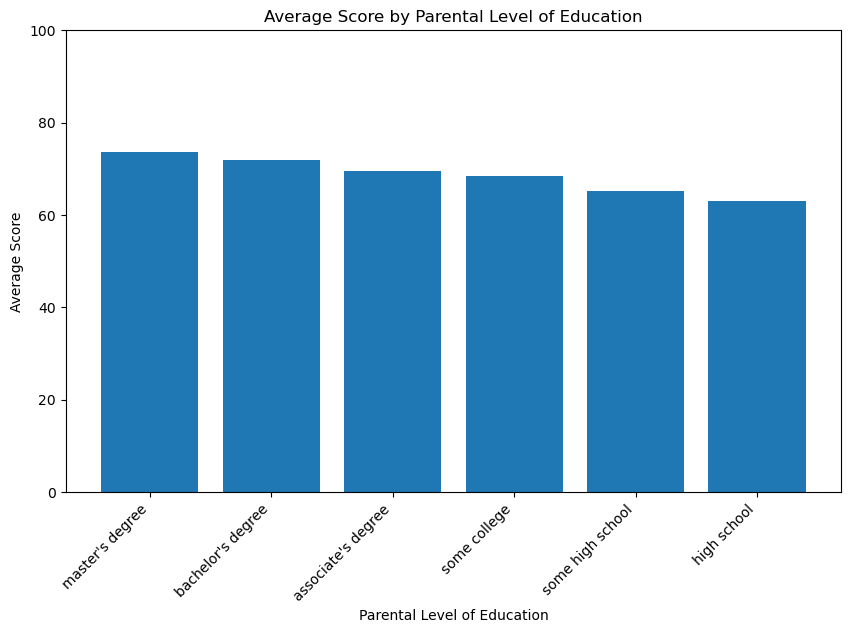

In [31]:
parental_avg = df.groupby("parental_level_of_education")["average_score"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(parental_avg.index, parental_avg.values)
plt.title("Average Score by Parental Level of Education")
plt.xlabel("Parental Level of Education")
plt.ylabel("Average Score")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
### Insight: Parental Education and Student Performance

This chart compares students' average scores based on parental level of education. It helps identify whether higher parental education levels are associated with stronger student exam outcomes.

In [ ]:
## Analysis by Lunch Type

Lunch type is used as a proxy for socioeconomic background in this dataset. This section compares student performance between students receiving standard lunch and students receiving free/reduced lunch.

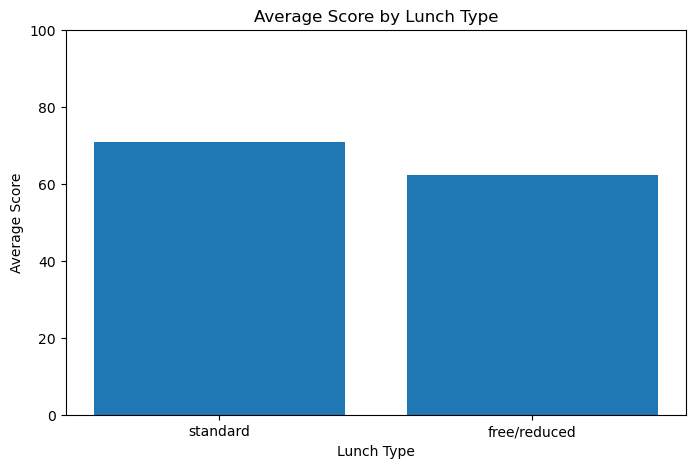

In [33]:
lunch_avg = df.groupby("lunch")["average_score"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(lunch_avg.index, lunch_avg.values)
plt.title("Average Score by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")
plt.ylim(0, 100)
plt.show()

In [ ]:
### Insight: Lunch Type and Student Performance

This chart compares average exam scores between students with standard lunch and students with free/reduced lunch. The result can help identify whether socioeconomic-related factors may be associated with academic performance.

In [ ]:
## Test Preparation Impact by Subject

This section compares math, reading, and writing scores between students who completed the test preparation course and students who did not.

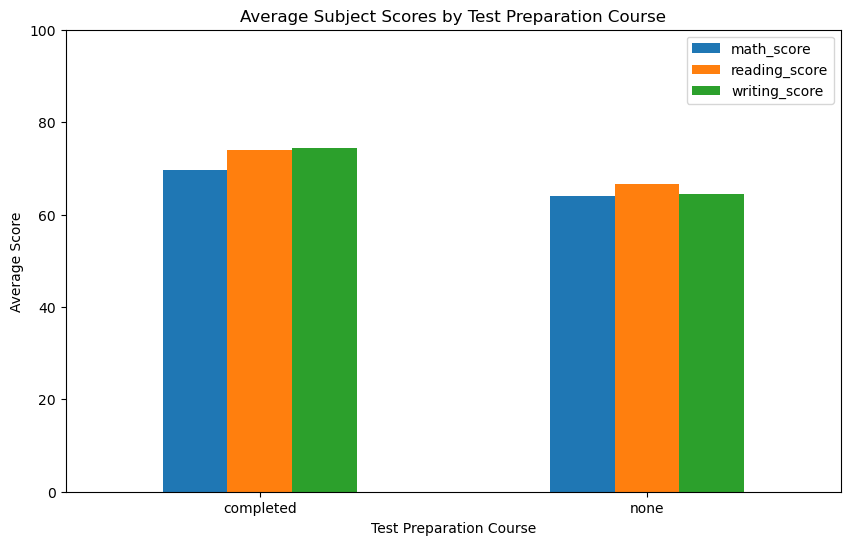

In [35]:
test_prep_subjects = df.groupby("test_preparation_course")[["math_score", "reading_score", "writing_score"]].mean()

test_prep_subjects.plot(kind="bar", figsize=(10, 6))
plt.title("Average Subject Scores by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.show()

In [ ]:
### Insight: Test Preparation by Subject

This chart shows how students performed in math, reading, and writing based on whether they completed the test preparation course. It helps identify whether test preparation is associated with improved performance across all subjects or only specific subjects.

In [ ]:
## Performance Level by Test Preparation Course

This section compares the number of high, average, and low performers among students who completed the test preparation course and those who did not.

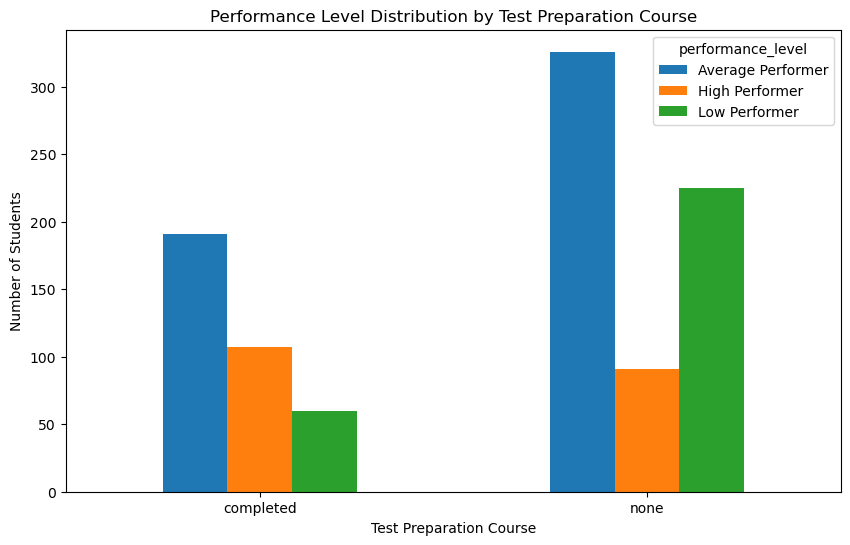

In [37]:
prep_performance = pd.crosstab(
    df["test_preparation_course"],
    df["performance_level"]
)

prep_performance.plot(kind="bar", figsize=(10, 6))
plt.title("Performance Level Distribution by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

In [ ]:
### Insight: Test Preparation and Performance Level

This chart shows the distribution of students across performance levels for each test preparation category. It helps determine whether students who completed test preparation are more likely to fall into higher performance groups.

In [ ]:
## Combined Analysis: Gender and Test Preparation

This section analyzes student performance by combining gender and test preparation course status.

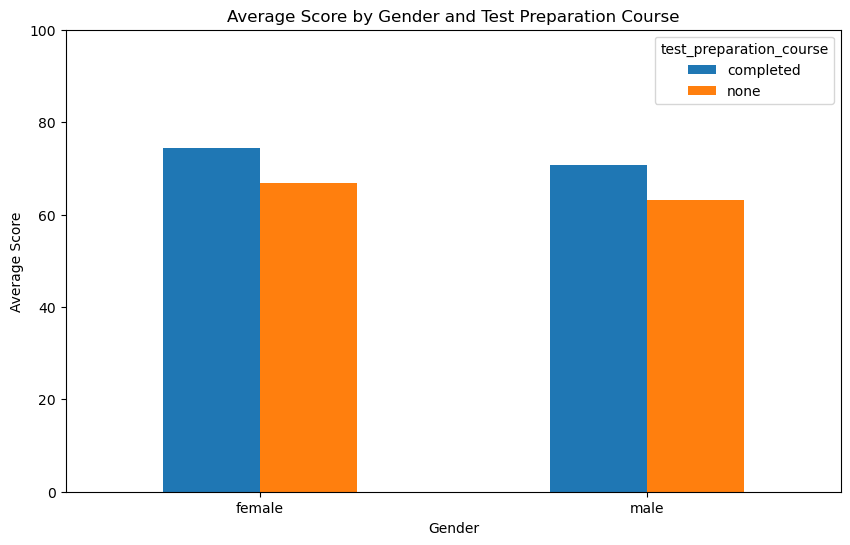

In [39]:
gender_prep_avg = df.groupby(["gender", "test_preparation_course"])["average_score"].mean().unstack()

gender_prep_avg.plot(kind="bar", figsize=(10, 6))
plt.title("Average Score by Gender and Test Preparation Course")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.show()

In [ ]:
### Insight: Gender and Test Preparation

This chart compares average student performance by both gender and test preparation status. It helps show whether test preparation is associated with higher scores for both male and female students.

In [41]:
group_combo = (
    df.groupby(["gender", "lunch", "test_preparation_course"])
    .agg(
        student_count=("student_id", "count"),
        avg_score=("average_score", "mean")
    )
    .reset_index()
)

group_combo = group_combo[group_combo["student_count"] >= 10]
group_combo = group_combo.sort_values("avg_score", ascending=False)

group_combo.head(10)

,gender,lunch,test_preparation_course,student_count,avg_score
2,female,standard,completed,114,77.479912
6,male,standard,completed,113,73.513009
3,female,standard,none,215,70.961023
0,female,free/reduced,completed,70,69.528714
4,male,free/reduced,completed,61,65.720984
7,male,standard,none,203,65.485911
1,female,free/reduced,none,119,59.501345
5,male,free/reduced,none,105,58.323714


In [ ]:
### Insight: Best Performing Group Combinations

This table identifies the highest-performing student groups based on gender, lunch type, and test preparation course status. Groups with fewer than 10 students were excluded to avoid drawing conclusions from very small sample sizes.

In [ ]:
## Key Findings

Based on the analysis, the following insights were identified:

1. Students who completed the test preparation course generally had higher average scores than students who did not complete it.
2. Lunch type showed a noticeable relationship with average exam performance, with students receiving standard lunch generally performing better than students receiving free/reduced lunch.
3. Average performance differed across parental education levels, suggesting that family educational background may be associated with student outcomes.
4. Reading and writing scores were generally stronger than math scores in the dataset.
5. Combined group analysis showed that test preparation and lunch type together may help explain differences in student performance.

## Conclusion

This project used PostgreSQL and Python to analyze student exam performance data. SQL was used to store, clean, transform, and query the dataset, while Python was used to create visualizations and summarize patterns. The analysis suggests that test preparation, lunch type, and parental education level are important factors associated with student exam performance.

## Limitations

This dataset does not include important variables such as study hours, attendance, school quality, teacher support, family income, or prior academic performance. Therefore, the results should be interpreted as associations, not direct causes.